In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.cloud import bigquery

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
PROJECT_ID = "nyc-taxi-analytics-1"

client = bigquery.Client(project=PROJECT_ID) 

In [4]:
def run_query(query: str) -> pd.DataFrame:
    """
    Run Bigquery SQL query and return result as a panda dataframe
    """

    query_job = client.query(query)
    result = query_job.result()
    return result.to_dataframe()

In [5]:
query_kpi = """
SELECT
    total_trips,
    total_revenue,
    total_fare,
    total_tip,
    total_tolls,
    avg_revenue_per_trip,
    avg_fare_per_trip,
    avg_tip_per_trip,
    avg_trip_distance,
    avg_trip_duration_minutes,
    overall_tip_rate_percentage,
    tipped_trip_percentage,
    credit_card_trip_percentage,
    cash_trip_percentage
FROM `nyc-taxi-analytics-1.nyc_taxi_dbt_reporting.rpt_kpi_overview`
"""

df_kpi = run_query(query_kpi)
df_kpi

,total_trips,total_revenue,total_fare,total_tip,total_tolls,avg_revenue_per_trip,avg_fare_per_trip,avg_tip_per_trip,avg_trip_distance,avg_trip_duration_minutes,overall_tip_rate_percentage,tipped_trip_percentage,credit_card_trip_percentage,cash_trip_percentage
0,35359307,"1,020,936,224.13","695,079,910.69","127,869,473.49","21,138,691.36",28.87,19.66,3.62,3.57,17.47,18.40,78.70,81.83,17.17


## Monthly Trend

In [6]:
query_monthly = """
SELECT
    pickup_year_month,
    total_trips,
    previous_month_trips,
    trips_mom_growth_percentage,
    total_revenue,
    previous_month_revenue,
    revenue_mom_growth_percentage,
    total_fare,
    total_tip,
    avg_revenue_per_trip,
    avg_trip_distance,
    avg_trip_duration_minutes
FROM `nyc-taxi-analytics-1.nyc_taxi_dbt_reporting.rpt_monthly_demand_revenue`
ORDER BY pickup_year_month
"""

df_monthly = run_query(query_monthly)
df_monthly

,pickup_year_month,total_trips,previous_month_trips,trips_mom_growth_percentage,total_revenue,previous_month_revenue,revenue_mom_growth_percentage,total_fare,total_tip,avg_revenue_per_trip,avg_trip_distance,avg_trip_duration_minutes
0,2023-01,2868243,<NA>,NaN,"78,298,334.10",NaN,NaN,"52,954,592.91","9,790,104.67",27.30,3.46,15.72
1,2023-02,2717287,2868243,-5.26,"74,005,116.26","78,298,334.10",-5.48,"49,880,864.33","9,352,528.93",27.23,3.38,16.02
2,2023-03,3169021,2717287,16.62,"89,231,212.21","74,005,116.26",20.57,"60,338,247.39","11,281,879.71",28.16,3.52,16.89
3,2023-04,3057587,3169021,-3.52,"87,552,922.91","89,231,212.21",-1.88,"59,622,474.28","10,938,957.45",28.63,3.60,17.28
4,2023-05,3260640,3057587,6.64,"95,591,416.52","87,552,922.91",9.18,"65,219,277.42","11,988,480.08",29.32,3.65,18.09
5,2023-06,3066303,3260640,-5.96,"90,215,417.74","95,591,416.52",-5.62,"61,658,588.51","11,226,278.82",29.42,3.72,17.72
6,2023-07,2694638,3066303,-12.12,"78,193,062.41","90,215,417.74",-13.33,"53,612,332.76","9,494,790.91",29.02,3.75,17.11
7,2023-08,2606299,2694638,-3.28,"75,900,018.16","78,193,062.41",-2.93,"51,891,241.98","9,155,639.42",29.12,3.75,17.10
8,2023-09,2584900,2606299,-0.82,"78,221,959.33","75,900,018.16",3.06,"53,746,592.53","9,744,027.83",30.26,3.70,18.77
9,2023-10,3218306,2584900,24.50,"95,540,264.16","78,221,959.33",22.14,"65,076,038.88","12,145,903.01",29.69,3.55,18.32


In [7]:
df_monthly.info()
df_monthly.describe()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   pickup_year_month              12 non-null     str    
 1   total_trips                    12 non-null     Int64  
 2   previous_month_trips           11 non-null     Int64  
 3   trips_mom_growth_percentage    11 non-null     float64
 4   total_revenue                  12 non-null     float64
 5   previous_month_revenue         11 non-null     float64
 6   revenue_mom_growth_percentage  11 non-null     float64
 7   total_fare                     12 non-null     float64
 8   total_tip                      12 non-null     float64
 9   avg_revenue_per_trip           12 non-null     float64
 10  avg_trip_distance              12 non-null     float64
 11  avg_trip_duration_minutes      12 non-null     float64
dtypes: Int64(2), float64(9), str(1)
memory usage: 1.4 KB


,total_trips,previous_month_trips,trips_mom_growth_percentage,total_revenue,previous_month_revenue,revenue_mom_growth_percentage,total_fare,total_tip,avg_revenue_per_trip,avg_trip_distance,avg_trip_duration_minutes
count,12.00,11.00,11.00,12.00,11.00,11.00,12.00,12.00,12.00,12.00,12.00
mean,"2,946,608.92","2,937,285.91",1.05,"85,078,018.68","84,757,438.85",1.67,"57,923,325.89","10,655,789.46",28.87,3.57,17.45
std,"241,660.95","251,182.59",10.79,"7,685,265.90","7,975,779.60",11.26,"5,245,593.03","1,076,110.69",0.91,0.14,0.94
min,"2,584,900.00","2,584,900.00",-12.12,"74,005,116.26","74,005,116.26",-13.33,"49,880,864.33","9,155,639.42",27.23,3.38,15.72
25%,"2,711,624.75","2,705,962.50",-4.98,"78,214,735.10","78,207,510.87",-5.55,"53,447,897.80","9,681,718.60",28.51,3.45,17.05
50%,"3,053,374.50","3,057,587.00",-3.28,"88,078,659.87","87,552,922.91",-1.88,"59,949,870.69","11,082,618.13",29.09,3.58,17.50
75%,"3,092,446.00","3,117,971.00",3.03,"89,740,432.06","89,898,760.62",6.12,"61,016,441.58","11,336,218.47",29.34,3.71,18.17
max,"3,260,640.00","3,260,640.00",24.50,"95,591,416.52","95,591,416.52",22.14,"65,219,277.42","12,145,903.01",30.26,3.75,18.77


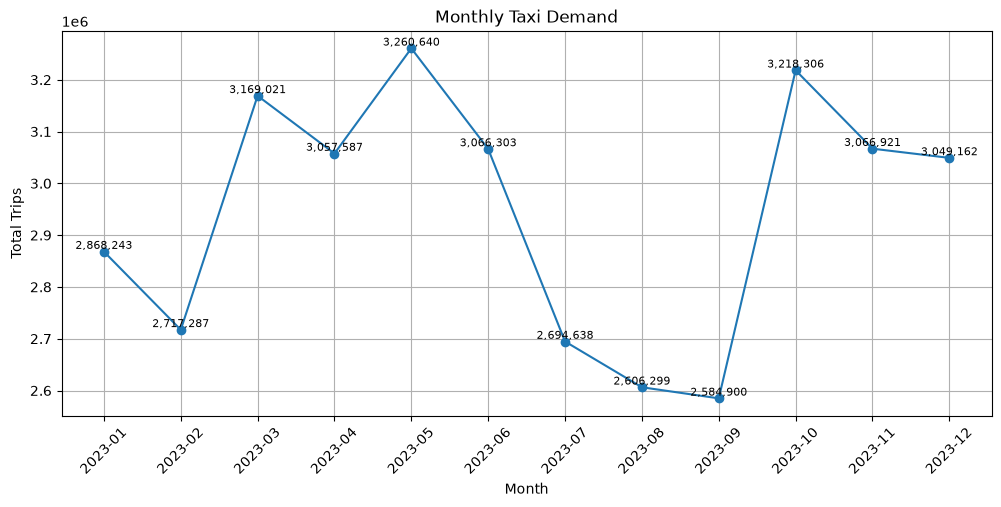

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(df_monthly["pickup_year_month"], df_monthly["total_trips"], marker="o")

for x, y in zip(df_monthly["pickup_year_month"], df_monthly["total_trips"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=8)

plt.title("Monthly Taxi Demand")
plt.xlabel("Month")
plt.ylabel("Total Trips")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Monthly Taxi Demand
Demand bulanan menunjukkan pola fluktuatif dengan puncaknya pada Mei dan Oktober. Penurunan paling jelas terjadi pada periode Juli hingga September, dengan titik terendah pada September. Kenaikan tajam pada Oktober menunjukkan adanya perbaikan demand.

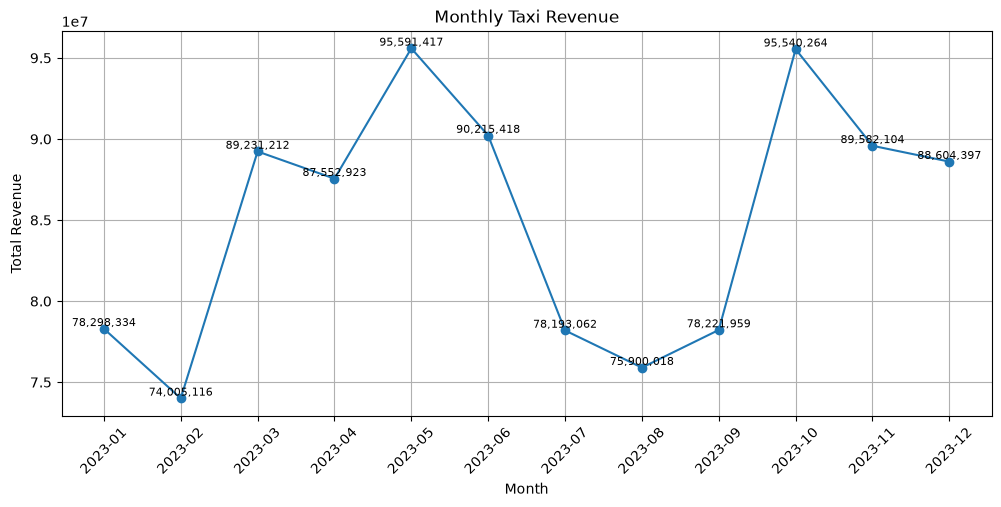

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(df_monthly["pickup_year_month"], df_monthly["total_revenue"], marker="o")

for x, y in zip(df_monthly["pickup_year_month"], df_monthly["total_revenue"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=8)

plt.title("Monthly Taxi Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Monthly Taxi Revenue
Revenue bulanan cenderung mengikuti pola demand, tetapi ada indikasi bahwa nilai revenue per trip juga berperan, terutama pada bulan ketika demand rendah tetapi revenue tidak turun sedalam jumlah trip.

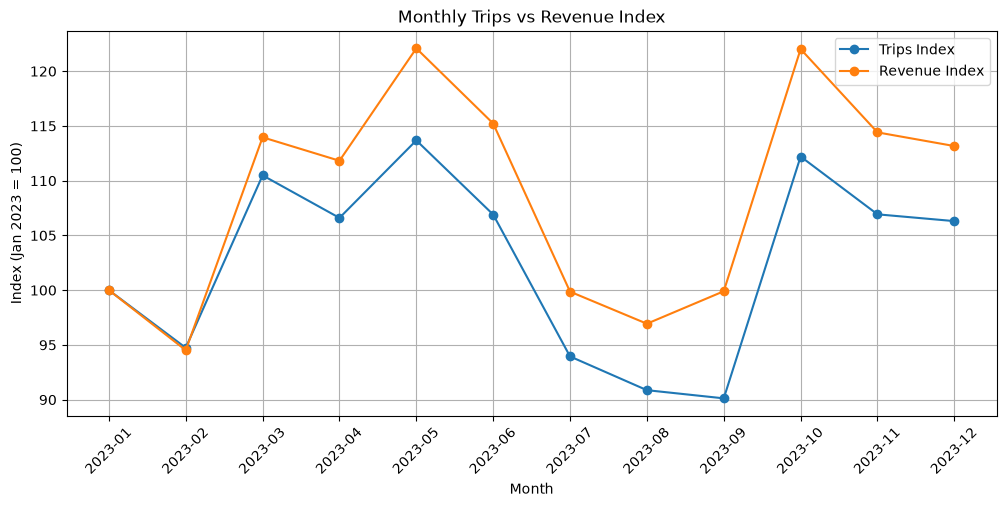

In [10]:
df_monthly["trips_index"] = (
    df_monthly["total_trips"] / df_monthly["total_trips"].iloc[0] * 100
)

df_monthly["revenue_index"] = (
    df_monthly["total_revenue"] / df_monthly["total_revenue"].iloc[0] * 100
)

plt.figure(figsize=(12, 5))
plt.plot(df_monthly["pickup_year_month"], df_monthly["trips_index"], marker="o", label="Trips Index")
plt.plot(df_monthly["pickup_year_month"], df_monthly["revenue_index"], marker="o", label="Revenue Index")
plt.title("Monthly Trips vs Revenue Index")
plt.xlabel("Month")
plt.ylabel("Index (Jan 2023 = 100)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

revenue bergerak searah dengan demand, tetapi revenue tumbuh lebih kuat daripada jumlah trip di banyak bulan. Ini berarti performa revenue tidak hanya ditentukan oleh volume, tetapi juga oleh nilai rata-rata per perjalanan.

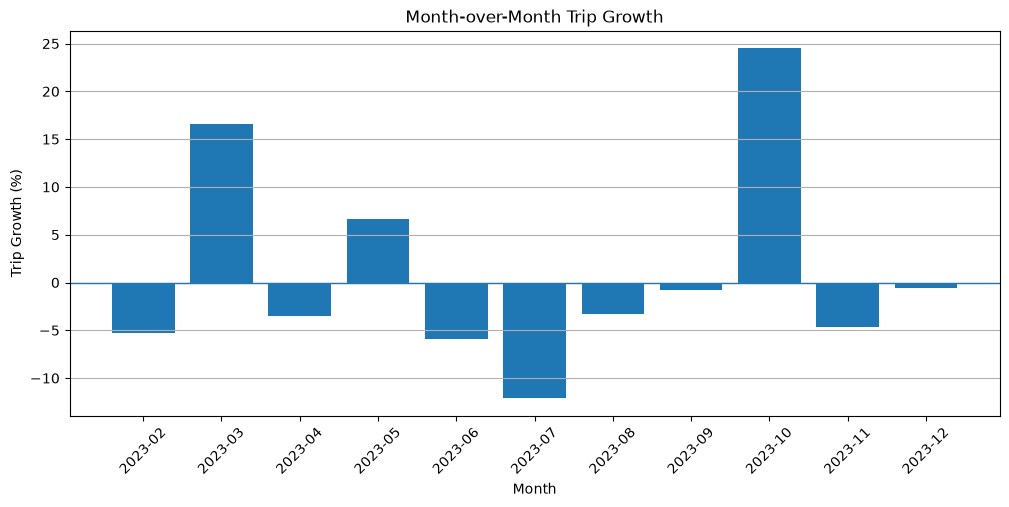

In [11]:
plt.figure(figsize=(12, 5))
plt.bar(
    df_monthly["pickup_year_month"],
    df_monthly["trips_mom_growth_percentage"]
)
plt.title("Month-over-Month Trip Growth")
plt.xlabel("Month")
plt.ylabel("Trip Growth (%)")
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.grid(axis="y")
plt.show()

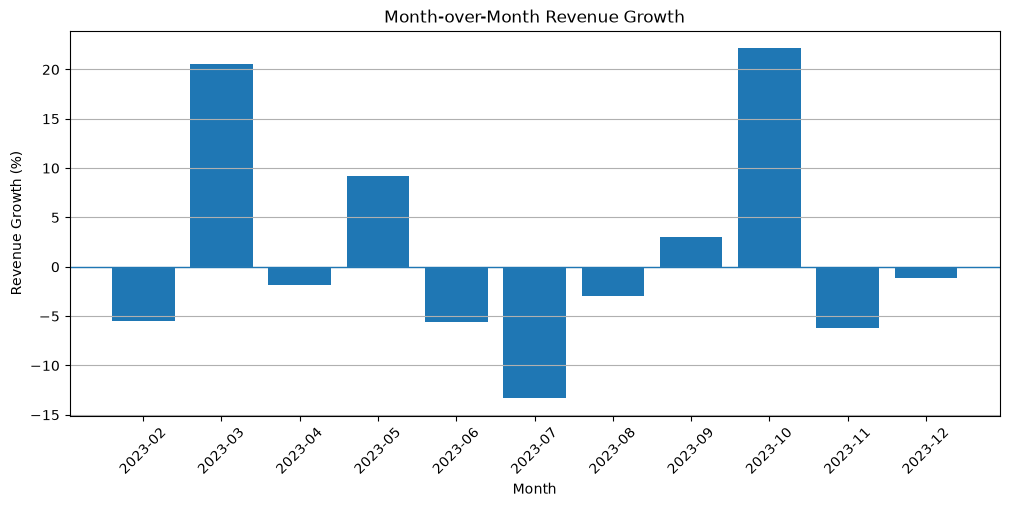

In [12]:
plt.figure(figsize=(12, 5))
plt.bar(
    df_monthly["pickup_year_month"],
    df_monthly["revenue_mom_growth_percentage"]
)
plt.title("Month-over-Month Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Revenue Growth (%)")
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.grid(axis="y")
plt.show()

### Month-over-month Trip and Revenue Growth
Analisis month-over-month menunjukkan bahwa pertumbuhan jumlah trip dan revenue secara umum bergerak searah sepanjang 2023. Pertumbuhan paling kuat terjadi pada Oktober, ketika jumlah trip meningkat sekitar 24% dan revenue meningkat sekitar 22% dibanding September. Hal ini menunjukkan adanya recovery yang kuat pada demand dan revenue setelah periode pelemahan di pertengahan tahun.

Penurunan terdalam terjadi pada Juli, ketika baik trip maupun revenue turun signifikan dibanding Juni. Ini menunjukkan bahwa pelemahan pada pertengahan tahun tidak hanya terjadi dari sisi volume perjalanan, tetapi juga berdampak langsung terhadap performa revenue.

Secara umum, revenue growth mengikuti arah trip growth, yang mengindikasikan bahwa total revenue sangat dipengaruhi oleh volume trip. Namun, September menjadi pengecualian menarik karena trip growth sedikit negatif, sementara revenue growth positif. Kondisi ini menunjukkan kemungkinan adanya peningkatan revenue per trip, yang dapat disebabkan oleh trip yang lebih panjang, fare lebih tinggi, tip lebih besar, atau perubahan komposisi perjalanan.

## Peak hour Analysis

In [13]:
query_peak_hour = """
SELECT
    pickup_hour,
    pickup_time_period,
    total_trips,
    total_revenue,
    avg_revenue_per_trip,
    avg_trip_distance,
    avg_trip_duration_minutes,
    demand_rank,
    revenue_rank
FROM `nyc-taxi-analytics-1.nyc_taxi_dbt_reporting.peak_hour_analysis`
ORDER BY pickup_hour
"""

df_peak_hour = run_query(query_peak_hour)
df_peak_hour.head()

,pickup_hour,pickup_time_period,total_trips,total_revenue,avg_revenue_per_trip,avg_trip_distance,avg_trip_duration_minutes,demand_rank,revenue_rank
0,0,Late night,993738,"29,104,583.22",29.29,4.00,15.92,17,17
1,1,Late night,664396,"17,739,452.95",26.70,3.56,15.17,19,19
2,2,Late night,435923,"10,986,456.87",25.20,3.37,14.02,21,21
3,3,Late night,282756,"7,461,934.98",26.39,3.55,14.34,22,22
4,4,Late night,176685,"5,936,501.38",33.60,5.01,15.62,24,24


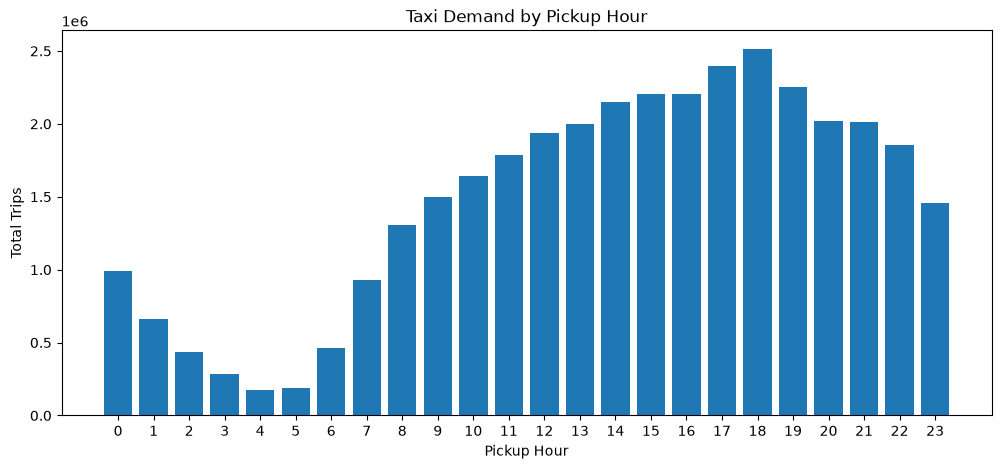

In [14]:
plt.figure(figsize=(12, 5))
plt.bar(df_peak_hour["pickup_hour"], df_peak_hour["total_trips"])
plt.title("Taxi Demand by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Total Trips")
plt.xticks(range(0, 24))
plt.show()

### Demand by Pickup Hour
Analisis demand per jam menunjukkan pola mobilitas harian yang jelas. Demand taxi berada pada titik terendah pada periode dini hari, terutama sekitar jam 04:00–05:00, kemudian mulai meningkat sejak jam 06:00 seiring dimulainya aktivitas harian. Demand terus meningkat sepanjang hari dan mencapai puncaknya pada periode sore hingga awal malam, terutama sekitar jam 18:00. Setelah jam 19:00, demand mulai menurun secara bertahap, tetapi tetap relatif tinggi hingga malam.

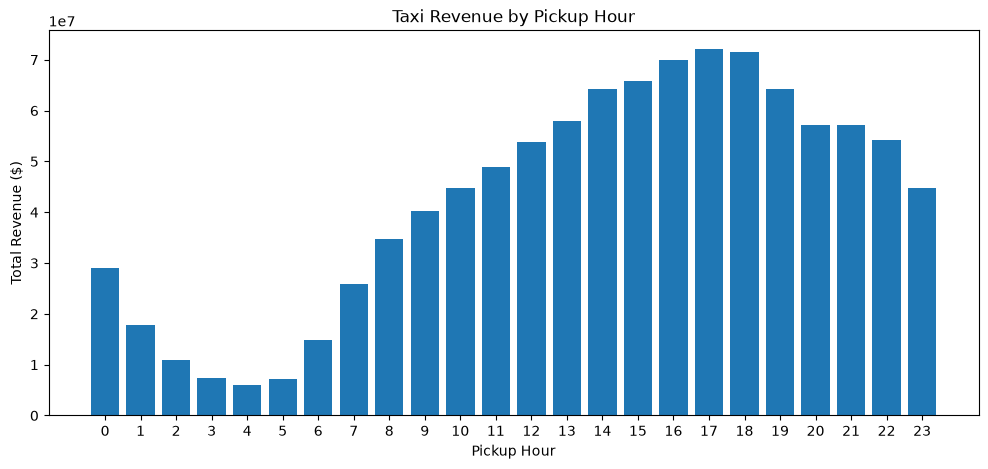

In [15]:
plt.figure(figsize=(12, 5))
plt.bar(df_peak_hour["pickup_hour"], df_peak_hour["total_revenue"])
plt.title("Taxi Revenue by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Total Revenue ($)")
plt.xticks(range(0, 24))
plt.show()


### Revenue by Pickup Hour
Pola revenue terlihat sangat mirip dengan pola demand, yang menunjukkan bahwa revenue per jam sangat dipengaruhi oleh volume trip. Revenue tertinggi terjadi sekitar jam 17:00–18:00, hampir sama dengan periode peak demand. Namun, peak revenue terlihat sedikit lebih awal dibanding peak demand, sehingga ada indikasi bahwa rata-rata revenue per trip pada jam 17:00 mungkin lebih tinggi dibanding jam 18:00. Analisis lanjutan terhadap average revenue per trip, trip distance, dan trip duration per jam diperlukan untuk memastikan hal tersebut.

Secara keseluruhan, periode sore hingga awal malam merupakan window operasional terkuat untuk Yellow Taxi, baik dari sisi demand maupun revenue. Sebaliknya, periode dini hari merupakan window dengan performa demand dan revenue paling rendah.

## Payment Behaviour

In [16]:
query_payment = f"""
SELECT
    payment_type_id,
    payment_type_name,
    payment_category,
    total_trips,
    trip_share_percentage,
    total_revenue,
    revenue_share_percentage,
    total_fare,
    total_tip,
    avg_revenue_per_trip,
    avg_fare_per_trip,
    avg_tip_per_trip,
    tip_rate_percentage,
    tipped_trip_percentage
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_payment_behaviour`
ORDER BY total_trips DESC
"""

df_payment = run_query(query_payment)
df_payment

,payment_type_id,payment_type_name,payment_category,total_trips,trip_share_percentage,total_revenue,revenue_share_percentage,total_fare,total_tip,avg_revenue_per_trip,avg_fare_per_trip,avg_tip_per_trip,tip_rate_percentage,tipped_trip_percentage
0,1,Credit card,Card payment,28934564,81.83,"858,074,425.90",84.05,"566,417,945.22","127,860,454.42",29.66,19.58,4.42,22.57,96.17
1,2,Cash,Cash payment,6071589,17.17,"153,934,564.22",15.08,"121,650,655.32","1,912.30",25.35,20.04,0.00,0.00,0.01
2,4,Dispute,Exception,235101,0.66,"6,113,382.81",0.60,"4,820,451.71","5,774.07",26.00,20.50,0.02,0.12,0.15
3,3,No charge,Non-revenue,118053,0.33,"2,813,851.20",0.28,"2,190,858.44","1,332.70",23.84,18.56,0.01,0.06,0.11


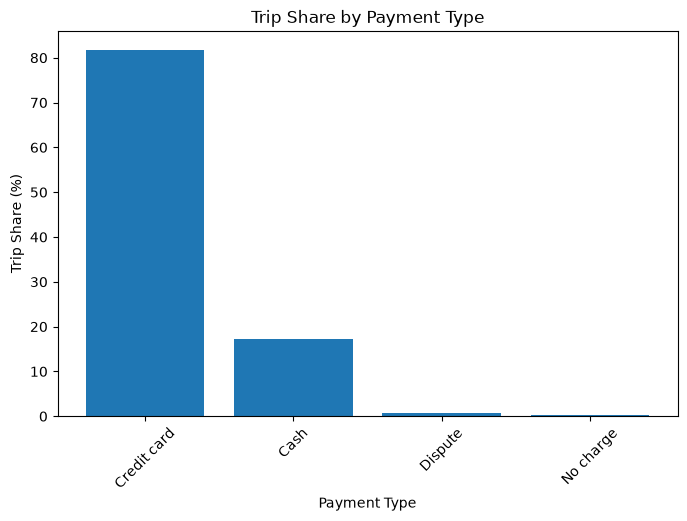

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(df_payment["payment_type_name"], df_payment["trip_share_percentage"])
plt.title("Trip Share by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Trip Share (%)")
plt.xticks(rotation=45)
plt.show()

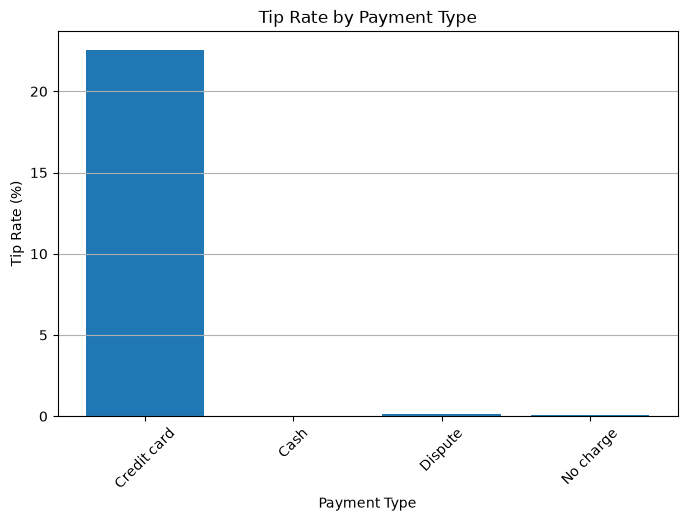

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(df_payment["payment_type_name"], df_payment["tip_rate_percentage"])
plt.title("Tip Rate by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Tip Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

Credit Card menjadi payment type dominan dengan kontribusi sekitar 82% dari total trip, sedangkan Cash menjadi kategori kedua dengan proporsi sekitar 17%. Kategori Dispute dan No charge hanya memiliki kontribusi sangat kecil.

## Location Performance

In [19]:
query_location = f"""
SELECT
    pickup_location_id,
    pickup_borough,
    pickup_zone,
    pickup_service_zone,
    total_trips,
    total_revenue,
    total_tip,
    avg_revenue_per_trip,
    avg_trip_distance,
    avg_trip_duration_minutes,
    trip_rank,
    revenue_rank,
    trip_contribution_percentage,
    revenue_contribution_percentage
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_location_performance`
ORDER BY total_trips DESC
LIMIT 20
"""

df_location = run_query(query_location)
df_location.head()

,pickup_location_id,pickup_borough,pickup_zone,pickup_service_zone,total_trips,total_revenue,total_tip,avg_revenue_per_trip,avg_trip_distance,avg_trip_duration_minutes,trip_rank,revenue_rank,trip_contribution_percentage,revenue_contribution_percentage
0,132,Queens,JFK Airport,Airports,1879779,"153,340,176.66","16,873,110.06",81.57,16.34,43.84,1,1,5.32,15.02
1,237,Manhattan,Upper East Side South,Yellow Zone,1700623,"35,144,177.38","4,588,303.44",20.67,1.81,12.91,2,4,4.81,3.44
2,161,Manhattan,Midtown Center,Yellow Zone,1673973,"42,350,361.53","5,488,232.91",25.30,2.57,16.39,3,3,4.73,4.15
3,236,Manhattan,Upper East Side North,Yellow Zone,1499585,"31,793,995.05","4,193,975.05",21.20,2.03,13.04,4,6,4.24,3.11
4,162,Manhattan,Midtown East,Yellow Zone,1289563,"31,573,705.21","4,118,831.75",24.48,2.45,15.47,5,7,3.65,3.09


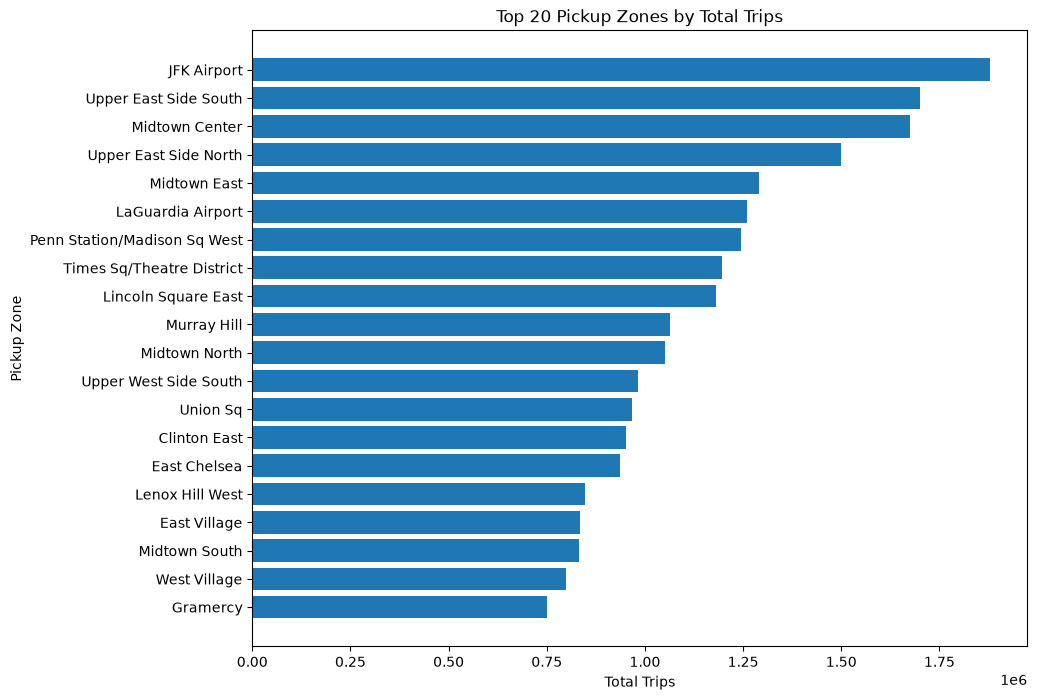

In [20]:
top_location = df_location.sort_values("total_trips", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_location["pickup_zone"], top_location["total_trips"])
plt.title("Top 20 Pickup Zones by Total Trips")
plt.xlabel("Total Trips")
plt.ylabel("Pickup Zone")
plt.show()

### Pickup Zones by Total Trips

Analisis performa lokasi menunjukkan bahwa demand taxi terkonsentrasi pada area airport dan zona-zona utama di Manhattan. JFK Airport menjadi pickup zone dengan jumlah trip tertinggi sekaligus kontributor revenue terbesar. Hal ini menunjukkan bahwa JFK Airport bukan hanya lokasi dengan demand tinggi, tetapi juga lokasi dengan nilai revenue yang sangat besar.

Beberapa zona Manhattan seperti Upper East Side South, Midtown Center, Upper East Side North, Midtown East, Penn Station/Madison Sq West, dan Times Sq/Theatre District masuk dalam top pickup zone berdasarkan jumlah trip. Ini menunjukkan bahwa demand Yellow Taxi sangat terkonsentrasi pada area bisnis, residensial, komersial, dan pusat aktivitas di Manhattan.

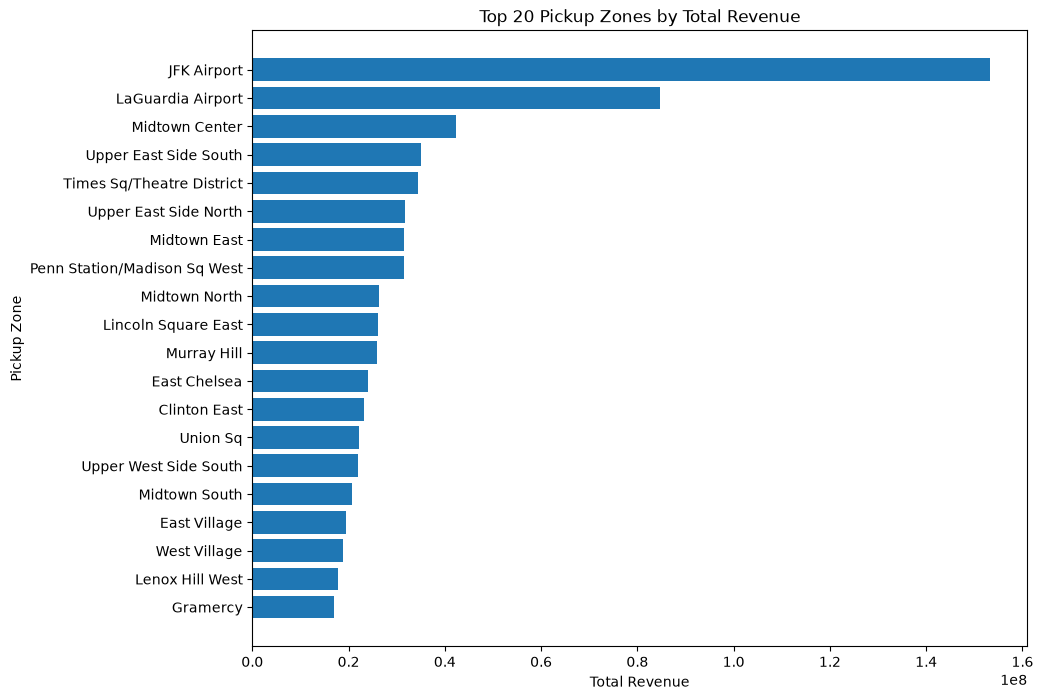

In [21]:
top_revenue_location = df_location.sort_values("total_revenue", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_revenue_location["pickup_zone"], top_revenue_location["total_revenue"])
plt.title("Top 20 Pickup Zones by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Pickup Zone")
plt.show()

### Pickup Zones by Total Revenue
ranking pickup zones berdasarkan revenue menunjukkan pola yang tidak sama dengan pickup zones berdasarkan total trip. Zona airport, terutama JFK Airport dan LaGuardia Airport, memberikan kontribusi revenue yang jauh lebih besar dibanding banyak zona Manhattan. Hal ini mengindikasikan bahwa trip dari airport kemungkinan memiliki average revenue per trip lebih tinggi karena jarak perjalanan lebih panjang, adanya airport fee, tolls, atau surcharge. Secara keseluruhan, zona Manhattan dapat dipahami sebagai high-volume demand centers, sedangkan airport zones merupakan high-value revenue centers.

In [22]:
query_sample = """
SELECT
    trip_id,
    pickup_year_month,
    pickup_hour,
    pickup_time_period,
    is_weekend,
    passenger_count,
    trip_distance,
    trip_duration_minutes,
    fare_amount,
    tip_amount,
    total_amount,
    fare_per_mile,
    tip_rate,
    payment_type_id,
    payment_type_name,
    trip_distance_bucket,
    trip_duration_bucket
FROM `nyc-taxi-analytics-1.nyc_taxi_dbt_marts.fact_yellow_taxi_trips`
WHERE RAND() < 0.01
LIMIT 100000
"""

df_sample = run_query(query_sample)
df_sample.head()

,trip_id,pickup_year_month,pickup_hour,pickup_time_period,is_weekend,passenger_count,trip_distance,trip_duration_minutes,fare_amount,tip_amount,total_amount,fare_per_mile,tip_rate,payment_type_id,payment_type_name,trip_distance_bucket,trip_duration_bucket
0,0f1b79353d2f524ec4dacbbdd5e49f9e,2023-07,20,Evening,False,3,0.15,3,4.40,0.00,9.40,29.33,0.00,2,Cash,0-1 mile,0-10 minutes
1,fd52f8f9ce9f17613c74f923a8eb71b6,2023-07,10,Morning,False,1,0.40,4,5.80,1.96,11.76,14.50,0.34,1,Credit card,0-1 mile,0-10 minutes
2,8f6489c668470995df1e9a1befc77b88,2023-07,19,Evening,False,1,0.73,4,5.80,2.00,14.30,7.95,0.34,1,Credit card,0-1 mile,0-10 minutes
3,50954a349e72508f761d57a3a83e4e39,2023-07,5,Late night,False,1,0.83,2,5.80,2.16,12.96,6.99,0.37,1,Credit card,0-1 mile,0-10 minutes
4,19db65f50199d8423f244cb6a92fdd12,2023-07,20,Evening,False,1,0.69,4,5.80,2.16,12.96,8.41,0.37,1,Credit card,0-1 mile,0-10 minutes


In [23]:
numeric_columns = [
    "passenger_count",
    "trip_distance",
    "trip_duration_minutes",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "fare_per_mile",
    "tip_rate"
]

df_sample[numeric_columns].describe()

,passenger_count,trip_distance,trip_duration_minutes,fare_amount,tip_amount,total_amount,fare_per_mile,tip_rate
count,"100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00"
mean,1.40,3.59,17.02,19.43,3.58,28.59,8.63,0.20
std,0.89,31.09,43.51,17.93,4.02,22.67,55.18,0.15
min,1.00,0.01,1.00,0.01,0.00,1.01,0.00,0.00
25%,1.00,1.09,8.00,9.30,1.00,15.95,5.62,0.09
50%,1.00,1.80,12.00,13.50,2.86,21.00,7.11,0.24
75%,1.00,3.40,20.00,21.20,4.42,30.24,8.91,0.29
max,6.00,"9,673.85","6,764.00",600.00,99.99,601.00,"8,500.00",5.67


1. passenger_count : jumlah penumpang  
2. trip_distance : jarak perjalanan  
3. trip_duration_minutes : surasi perjalanan  
4. fare_amount : tarif dasar  
5. tip_amount : jumlah tip  
6. total_amount : total pembayaran  
7. fare_per_mile : tarif per mil  
8. tip_rate : rasio tip terhadap tarif dasar   

In [24]:
df_sample.isna().sum()

trip_id                  0
pickup_year_month        0
pickup_hour              0
pickup_time_period       0
is_weekend               0
passenger_count          0
trip_distance            0
trip_duration_minutes    0
fare_amount              0
tip_amount               0
total_amount             0
fare_per_mile            0
tip_rate                 0
payment_type_id          0
payment_type_name        0
trip_distance_bucket     0
trip_duration_bucket     0
dtype: int64

In [25]:
df_sample["payment_type_name"].value_counts()

payment_type_name
Credit card    81306
Cash           17673
Dispute          684
No charge        337
Name: count, dtype: int64

In [26]:
df_sample["pickup_time_period"].value_counts()

pickup_time_period
Evening       32409
Midday        28727
Morning       16621
Night         14530
Late night     7713
Name: count, dtype: int64

In [27]:
df_sample["trip_distance_bucket"].value_counts()

trip_distance_bucket
1-3 miles      48945
0-1 mile       22390
3-5 miles      11470
5-10 miles      8540
10-20 miles     7546
20+ miles       1109
Name: count, dtype: int64

In [28]:
df_sample["trip_duration_bucket"].value_counts()

trip_duration_bucket
0-10 minutes     41131
10-20 minutes    34763
20-40 minutes    18650
40-60 minutes     4017
60+ minutes       1439
Name: count, dtype: int64

In [29]:
def plot_histogram(dataframe: pd.DataFrame, column: str, title: str, xlabel: str, bins: int = 50):
    plt.figure(figsize=(10, 5))
    plt.hist(dataframe[column].dropna(), bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.grid(axis="y")
    plt.show()

def plot_boxplot(dataframe: pd.DataFrame, column: str, title: str, xlabel: str):
    plt.figure(figsize=(8, 5))
    plt.boxplot(dataframe[column].dropna(), vert=False)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.grid(axis="x")
    plt.show()

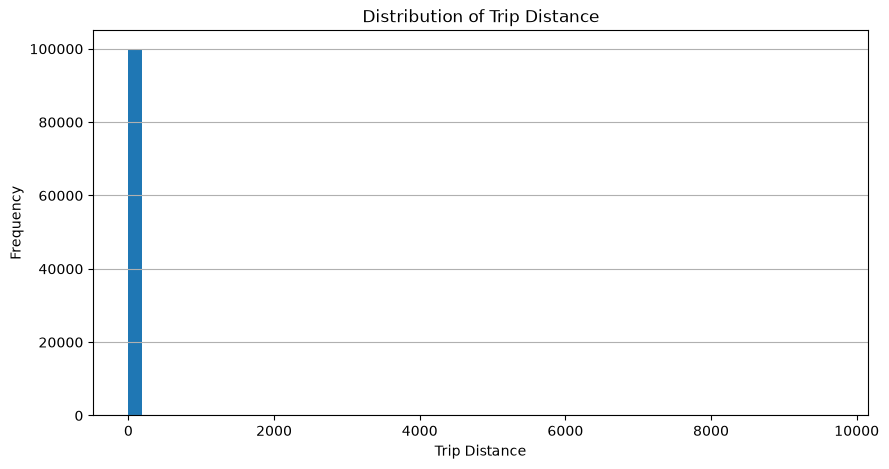

/tmp/ipykernel_4696/3320025711.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(dataframe[column].dropna(), vert=False)


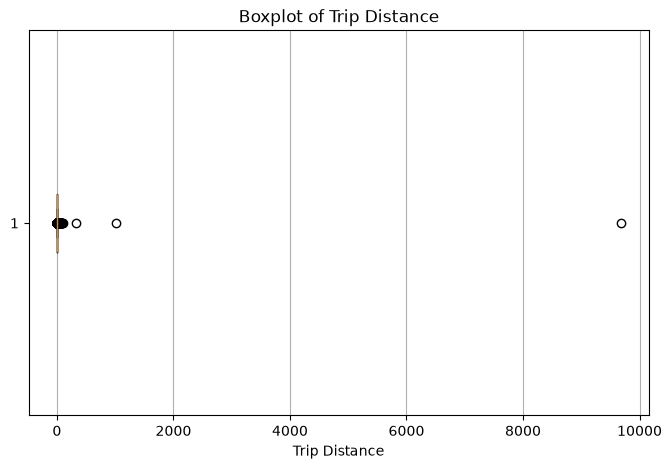

In [30]:
plot_histogram(
    dataframe=df_sample,
    column="trip_distance",
    title="Distribution of Trip Distance",
    xlabel="Trip Distance"
)

plot_boxplot(
    dataframe=df_sample,
    column="trip_distance",
    title="Boxplot of Trip Distance",
    xlabel="Trip Distance"
)

Histogram trip distance menunjukkan bahwa mayoritas perjalanan berada pada jarak pendek. Sebagian besar trip terkonsentrasi pada rentang jarak rendah, terutama di sekitar 0–5 miles, sedangkan hanya sebagian kecil trip yang memiliki jarak lebih jauh.

Kotak utama berada sangat dekat dengan nilai rendah, yang menunjukkan bahwa 50% data utama memiliki jarak perjalanan relatif pendek. Namun, terdapat banyak titik outlier di sisi kanan, bahkan mencapai lebih dari 100 miles. Nilai ekstrem ini belum tentu merupakan data salah, karena bisa saja merepresentasikan airport trips, perjalanan antar wilayah, atau long-distance trips.

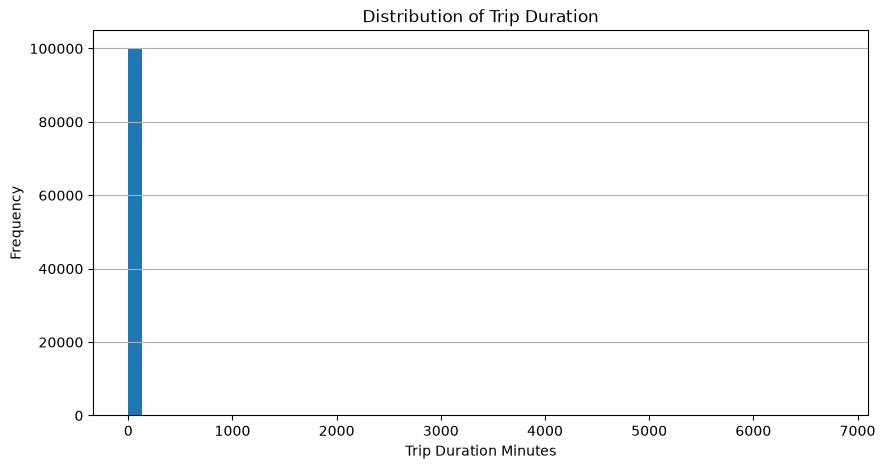

/tmp/ipykernel_4696/3320025711.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(dataframe[column].dropna(), vert=False)


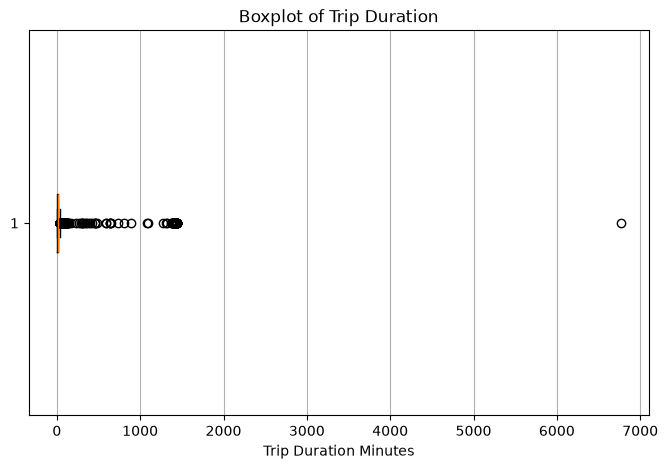

In [31]:
plot_histogram(
    dataframe=df_sample,
    column="trip_duration_minutes",
    title="Distribution of Trip Duration",
    xlabel="Trip Duration Minutes"
)

plot_boxplot(
    dataframe=df_sample,
    column="trip_duration_minutes",
    title="Boxplot of Trip Duration",
    xlabel="Trip Duration Minutes"
)

Histogram trip duration menunjukkan bahwa mayoritas perjalanan memiliki durasi pendek hingga sedang. Sebagian besar data terkonsentrasi sangat kuat di sisi kiri, sementara terdapat ekor panjang ke kanan yang menunjukkan adanya perjalanan dengan durasi sangat tinggi.

Boxplot trip duration menunjukkan indikasi outlier yang paling kuat dibandingkan metrik lainnya. Mayoritas durasi trip berada pada rentang rendah, tetapi terdapat sejumlah titik outlier yang sangat jauh dari distribusi utama, bahkan mencapai lebih dari 1.000 menit. Nilai durasi yang sangat panjang seperti ini lebih mencurigakan karena dapat mengindikasikan anomali data.

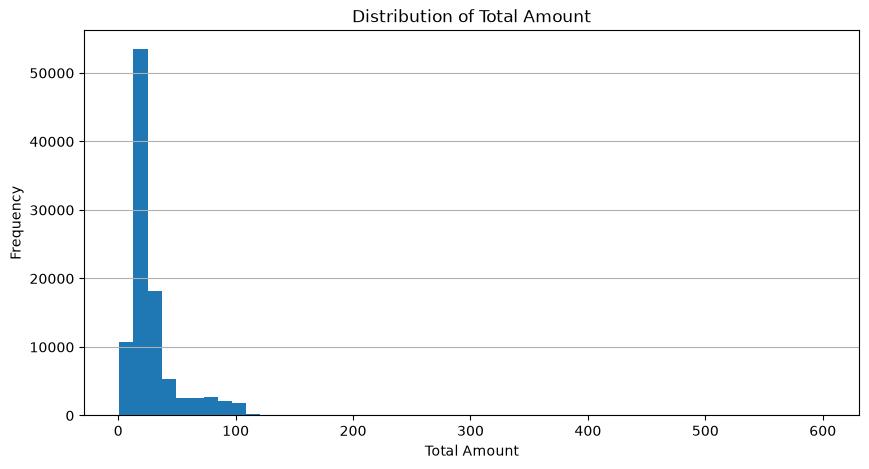

/tmp/ipykernel_4696/3320025711.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(dataframe[column].dropna(), vert=False)


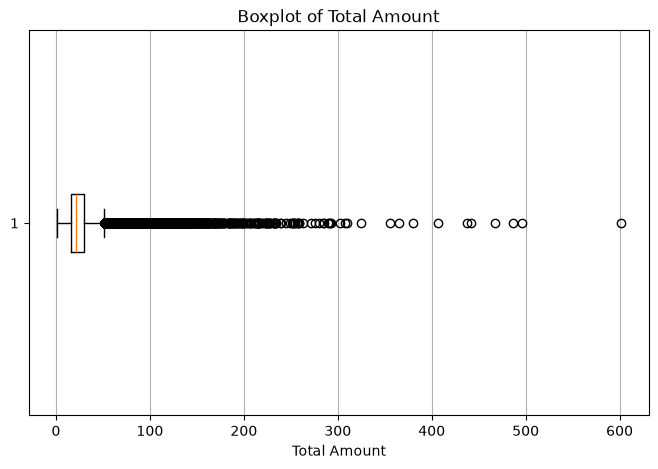

In [32]:
plot_histogram(
    dataframe=df_sample,
    column="total_amount",
    title="Distribution of Total Amount",
    xlabel="Total Amount"
)

plot_boxplot(
    dataframe=df_sample,
    column="total_amount",
    title="Boxplot of Total Amount",
    xlabel="Total Amount"
)

Histogram total amount menunjukkan bahwa mayoritas trip memiliki total pembayaran rendah hingga sedang. Sebagian besar nilai terkonsentrasi pada rentang total amount yang relatif kecil, sementara sebagian kecil trip memiliki total amount yang jauh lebih tinggi.

Boxplot total amount menunjukkan adanya beberapa high-value trips sebagai kandidat outlier. Sebagian besar pembayaran berada dalam rentang yang relatif sempit, tetapi terdapat titik-titik ekstrem di sisi kanan, bahkan mencapai ratusan dollar. Nilai total amount yang tinggi tidak selalu berarti data salah, karena bisa saja berasal dari perjalanan jarak jauh, airport trips, tolls, surcharge, atau tip yang besar. Namun, nilai ekstrem ini tetap perlu divalidasi dengan metrik lain seperti trip distance, trip duration, fare amount, fare per mile, tip amount, dan pickup/dropoff location.

In [33]:
correlation_columns = [
    "passenger_count",
    "trip_distance",
    "trip_duration_minutes",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "fare_per_mile",
    "tip_rate"
]

corr_matrix = df_sample[correlation_columns].corr(numeric_only=True)
corr_matrix

,passenger_count,trip_distance,trip_duration_minutes,fare_amount,tip_amount,total_amount,fare_per_mile,tip_rate
passenger_count,1.00,0.01,0.03,0.05,0.01,0.04,0.00,-0.03
trip_distance,0.01,1.00,0.04,0.14,0.09,0.14,-0.01,-0.02
trip_duration_minutes,0.03,0.04,1.00,0.26,0.15,0.25,-0.01,-0.06
fare_amount,0.05,0.14,0.26,1.00,0.61,0.98,0.02,-0.15
tip_amount,0.01,0.09,0.15,0.61,1.00,0.73,-0.01,0.44
total_amount,0.04,0.14,0.25,0.98,0.73,1.00,0.01,-0.04
fare_per_mile,0.00,-0.01,-0.01,0.02,-0.01,0.01,1.00,-0.01
tip_rate,-0.03,-0.02,-0.06,-0.15,0.44,-0.04,-0.01,1.00


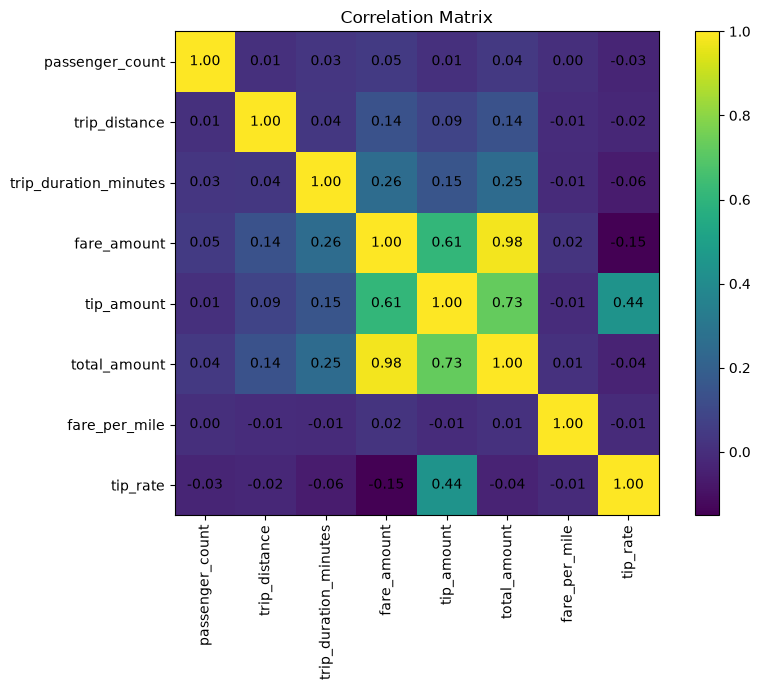

In [45]:
plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

korelasi menunjukkan bahwa total_amount memiliki hubungan paling kuat dengan fare_amount, dengan nilai korelasi 0.98. Hal ini menunjukkan bahwa fare dasar merupakan driver utama revenue per trip. Tip_amount juga memiliki hubungan positif yang kuat dengan total_amount, dengan korelasi 0.73, sehingga tip dapat dianggap sebagai komponen penting dalam total revenue.

Trip_duration_minutes memiliki korelasi positif lemah hingga sedang terhadap total_amount, sedangkan trip_distance menunjukkan korelasi yang cukup rendah. Hal ini mengindikasikan bahwa revenue tidak hanya dijelaskan oleh jarak perjalanan, tetapi juga dapat dipengaruhi oleh faktor lain seperti rate code, airport-related trips, tolls, surcharge, serta keberadaan outlier.

Passenger_count hampir tidak memiliki korelasi dengan total_amount, sehingga jumlah penumpang bukan faktor utama pembentuk revenue. Tip_rate juga memiliki korelasi yang sangat lemah terhadap total_amount karena tip_rate merepresentasikan perilaku tipping secara relatif, bukan nilai pembayaran absolut.

Secara keseluruhan, hasil korelasi menunjukkan bahwa total_amount terutama dipengaruhi oleh fare_amount dan tip_amount. Namun, karena data memiliki distribusi right-skewed dan nilai ekstrem, hasil korelasi ini perlu dibaca dengan hati-hati dan sebaiknya dibandingkan kembali setelah tahap outlier analysis.

In [36]:
payment_tip_summary = (
    df_sample
    .groupby("payment_type_name", as_index=False)
    .agg(
        total_trips=("trip_id", "count"),
        avg_tip_amount=("tip_amount", "mean"),
        avg_tip_rate=("tip_rate", "mean"),
        avg_total_amount=("total_amount", "mean")
    )
    .sort_values("total_trips", ascending=False)
)

payment_tip_summary

,payment_type_name,total_trips,avg_tip_amount,avg_tip_rate,avg_total_amount
1,Credit card,81306,4.40,0.25,29.45
0,Cash,17673,0.00,0.00,24.87
2,Dispute,684,0.12,0.00,25.68
3,No charge,337,0.00,0.00,22.91


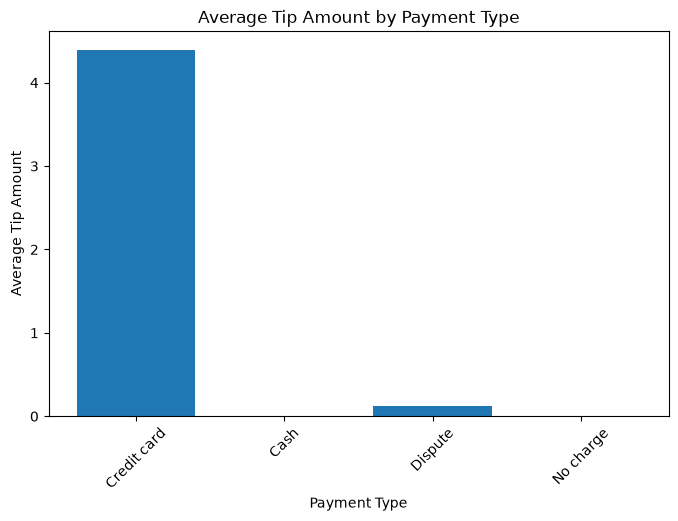

In [38]:
plt.figure(figsize=(8, 5))
plt.bar(payment_tip_summary["payment_type_name"], payment_tip_summary["avg_tip_amount"])
plt.title("Average Tip Amount by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Tip Amount")
plt.xticks(rotation=45)
plt.show()

In [42]:
weekend_summary = (
    df_sample
    .groupby("is_weekend", as_index=False)
    .agg(
        total_trips=("trip_id", "count"),
        avg_trip_distance=("trip_distance", "mean"),
        avg_trip_duration=("trip_duration_minutes", "mean"),
        avg_total_amount=("total_amount", "mean"),
        avg_tip_amount=("tip_amount", "mean")
    )
)

weekend_summary["day_type"] = weekend_summary["is_weekend"].map({
    True: "Weekend",
    False: "Weekday"
})

weekend_summary

,is_weekend,total_trips,avg_trip_distance,avg_trip_duration,avg_total_amount,avg_tip_amount,day_type
0,False,74101,3.60,17.33,28.86,3.64,Weekday
1,True,25899,3.57,16.11,27.82,3.40,Weekend


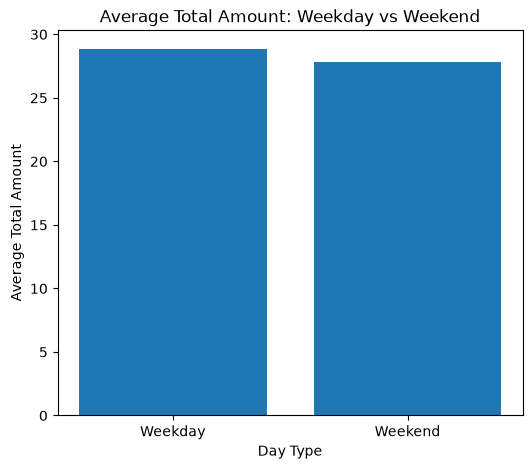

In [40]:
plt.figure(figsize=(6, 5))
plt.bar(weekend_summary["day_type"], weekend_summary["avg_total_amount"])
plt.title("Average Total Amount: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Total Amount")
plt.show()

Weekday memiliki average total amount sedikit lebih tinggi dibanding weekend, tetapi selisihnya kecil. Perbedaan ini perlu divalidasi dengan metrik pendukung seperti jarak, durasi, fare, dan tip sebelum dijadikan insight final.